# Preprocessing, EDA, and Feature Engineering


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("online_retail_indian_augmented.csv")
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (808548, 17)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Is_Return,Total_Price,City,State,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base,Multi_Size_Order
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,0,83.4,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.210705,0.184411,85048.0,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.296208,0.184411,79323.0,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.332672,0.184411,79323.0,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,0,100.8,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.101050,0.184411,22041.0,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,0,30.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.147180,0.184411,21232.0,True


## 2. Basic Data Overview
Understanding the data types, missing values, and summary statistics.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808548 entries, 0 to 808547
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Invoice                  808548 non-null  object 
 1   StockCode                808548 non-null  object 
 2   Description              808548 non-null  object 
 3   Quantity                 808548 non-null  int64  
 4   InvoiceDate              808548 non-null  object 
 5   Price                    808548 non-null  float64
 6   Customer ID              808548 non-null  float64
 7   Is_Return                808548 non-null  int64  
 8   Total_Price              808548 non-null  float64
 9   City                     808548 non-null  object 
 10  State                    808548 non-null  object 
 11  Latitude                 808548 non-null  float64
 12  Longitude                808548 non-null  float64
 13  Product_Return_Rate      808548 non-null  float64
 14  User

In [4]:
df.describe()

,Quantity,Price,Customer ID,Is_Return,Total_Price,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base
count,808548.000000,808548.000000,808548.000000,808548.000000,808548.000000,808548.000000,808548.000000,808548.000000,808548.000000,808208.000000
mean,9.681417,2.996420,15330.913721,0.130000,15.856822,22.226405,79.842707,0.129758,0.122862,33160.448346
std,142.155591,4.708232,1694.106620,0.336303,147.995261,5.693472,5.359979,0.060540,0.052215,22985.823087
min,-74215.000000,0.000000,12346.000000,0.000000,-77183.600000,8.524100,70.057700,0.000000,0.000000,10002.000000
25%,1.000000,1.250000,13979.000000,0.000000,2.550000,18.520400,76.216300,0.098341,0.097811,21794.000000
50%,4.000000,1.950000,15271.000000,0.000000,9.900000,23.176500,78.119800,0.120977,0.117383,22472.000000
75%,12.000000,3.750000,16797.000000,0.000000,17.700000,26.539300,84.186600,0.147643,0.139086,23284.000000
max,74215.000000,649.500000,18287.000000,1.000000,77183.600000,34.083700,95.355800,1.000000,1.000000,90214.000000


In [5]:
missing = df.isnull().sum()
print(missing[missing > 0])

StockCode_Base    340
dtype: int64


## 3. Feature Engineering

### 3.1 Return Rates (User & Product)

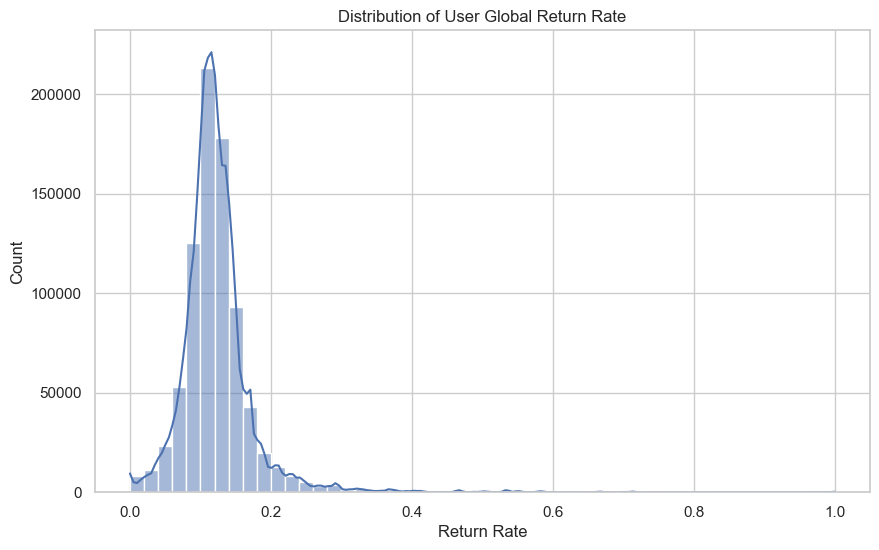

In [6]:
# Visualizing User Global Return Rate
plt.figure(figsize=(10, 6))
sns.histplot(df['User_Global_Return_Rate'], bins=50, kde=True)
plt.title('Distribution of User Global Return Rate')
plt.xlabel('Return Rate')
plt.show()

### 3.2 Defining the Fraud Label (`Is_Fraud`)
This is our Target Variable construction. We define a transaction as **Fraudulent** if:
1. It is a **Return** (`Is_Return == 1`) **AND**
2. The User has a **High Return Rate** (> 70%) **OR** it involves **Multi-Size Ordering**.

In [7]:
# Fraud Logic Application
conditions = (
    (df['Is_Return'] == 1) & 
    ((df['User_Global_Return_Rate'] > 0.7) | (df['Multi_Size_Order'] == True))
)
df['Is_Fraud'] = np.where(conditions, 1, 0)

fraud_counts = df['Is_Fraud'].value_counts()
print(f"Fraud Distribution:\n{fraud_counts}")
print(f"Fraud Percentage: {df['Is_Fraud'].mean() * 100:.2f}%")

Fraud Distribution:
Is_Fraud
0    766240
1     42308
Name: count, dtype: int64
Fraud Percentage: 5.23%


C:\Users\sanna\AppData\Local\Temp\ipykernel_31768\276486334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Fraud', data=df, palette='viridis')


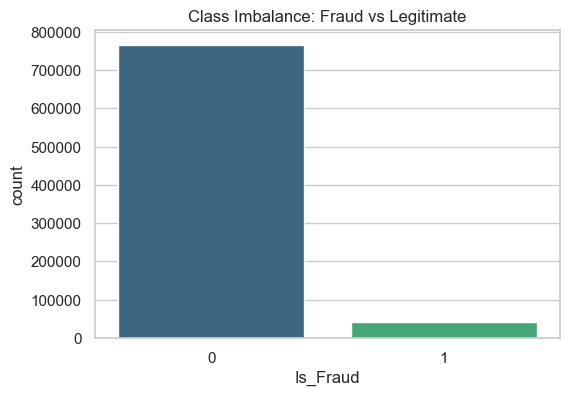

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Is_Fraud', data=df, palette='viridis')
plt.title('Class Imbalance: Fraud vs Legitimate')
plt.show()

### 3.3 Date & Time Features
Extracting temporal patterns from `InvoiceDate`.

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

print("Date Features Added: Hour, Month, DayOfWeek")

Date Features Added: Hour, Month, DayOfWeek


## 4. Exploratory Data Analysis (EDA)

### 4.1 Fraud by Time of Day

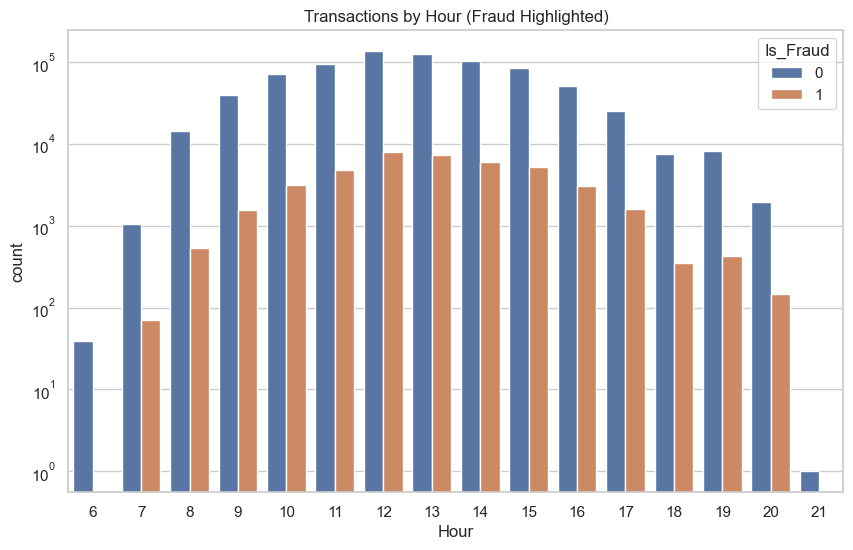

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Hour', hue='Is_Fraud', data=df)
plt.title('Transactions by Hour (Fraud Highlighted)')
plt.yscale('log') # Log scale because fraud is rare
plt.show()

### 4.2 Feature Correlation

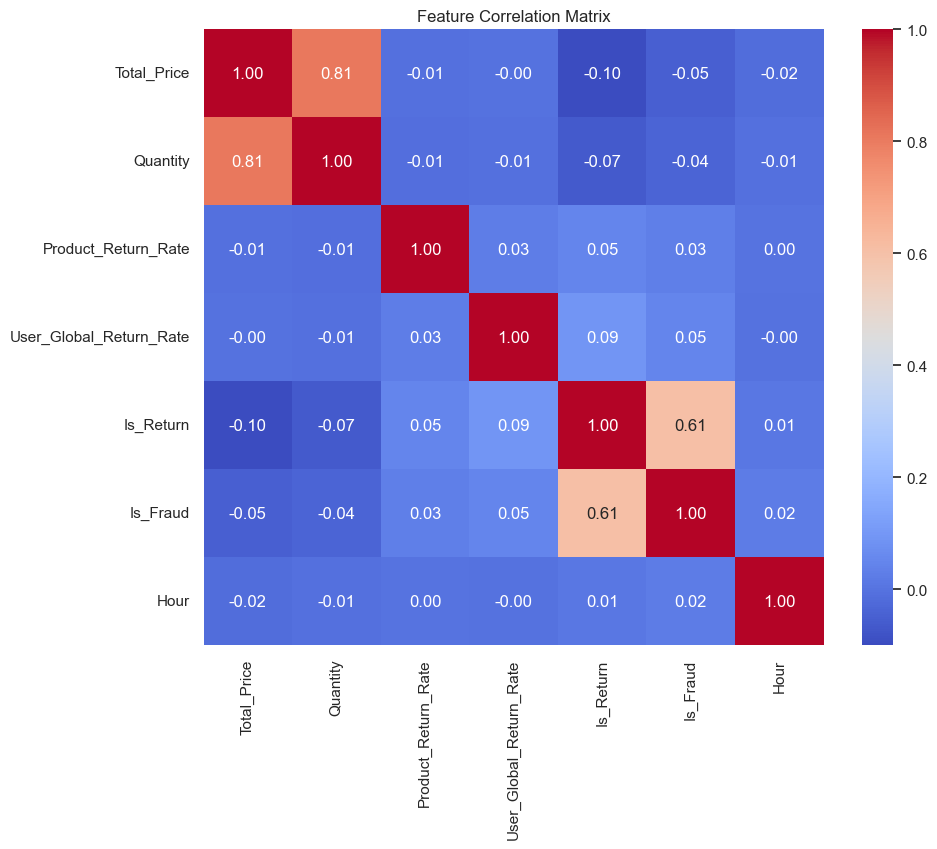

In [11]:
# Select numerical columns for correlation
corr_cols = ['Total_Price', 'Quantity', 'Product_Return_Rate', 'User_Global_Return_Rate', 'Is_Return', 'Is_Fraud', 'Hour']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### 4.3 Geospatial Analysis (Sales Hotspots)
Using Latitude and Longitude to visualize sales density.

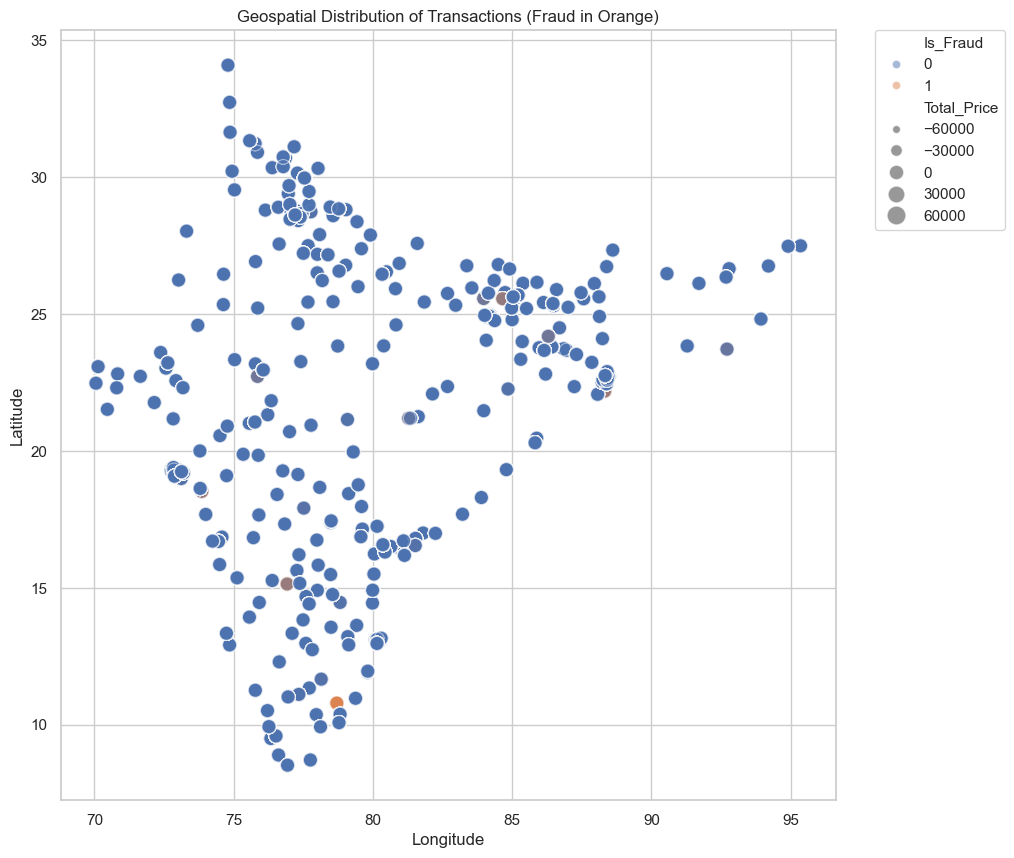

In [12]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x='Longitude', y='Latitude', hue='Is_Fraud', data=df, alpha=0.5, size='Total_Price', sizes=(10, 200))
plt.title('Geospatial Distribution of Transactions (Fraud in Orange)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

### 4.4 Top Cities by Fraud Count

C:\Users\sanna\AppData\Local\Temp\ipykernel_31768\3737869197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_city.values, y=fraud_by_city.index, palette='magma')


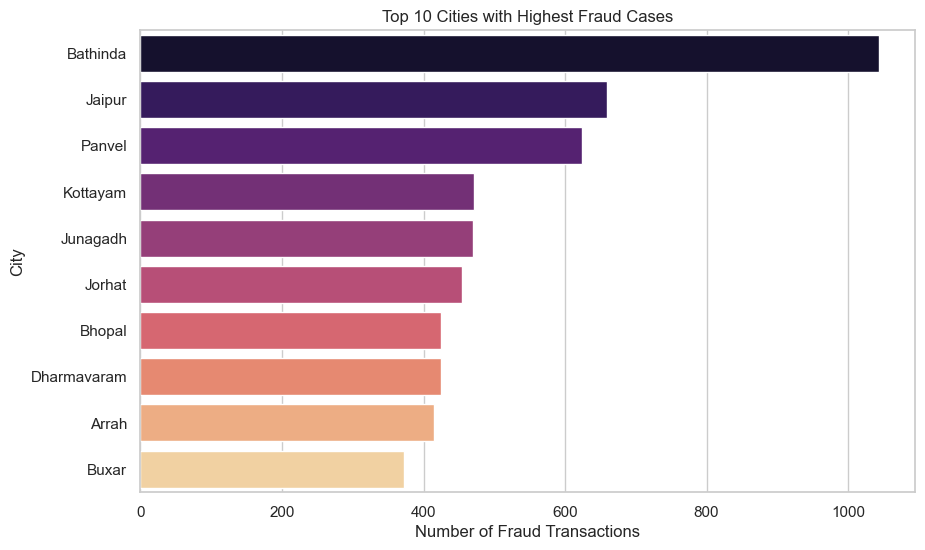

In [13]:
fraud_by_city = df[df['Is_Fraud'] == 1]['City'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_city.values, y=fraud_by_city.index, palette='magma')
plt.title('Top 10 Cities with Highest Fraud Cases')
plt.xlabel('Number of Fraud Transactions')
plt.show()

### 4.5 Geospatial Hotspot Analysis (Interactive Map)
Using Folium to visualize fraud density across India with circles indicating fraud cases.

In [14]:
import folium

# Aggregate data for the map
city_stats = df.groupby(['City', 'Latitude', 'Longitude']).agg(
    Total_Transactions=('Invoice', 'count'),
    Fraud_Cases=('Is_Fraud', 'sum'),
    Fraud_Rate=('Is_Fraud', 'mean')
).reset_index()

# Filter cities with at least one fraud case for visualization
fraud_cities = city_stats[city_stats['Fraud_Cases'] > 0]

# Initialize Map centered on India
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5, tiles='OpenStreetMap')

# Add circles for fraud hotspots
for _, row in fraud_cities.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5 + (row['Fraud_Cases'] / 10),  # Scale radius by fraud count
        popup=f"{row['City']}: {row['Fraud_Cases']} Fraud Cases (Rate: {row['Fraud_Rate']:.2%})",
        color='red',
        fill=True,
        fill_color='orange',
        fill_opacity=0.6
    ).add_to(m)

# Save map to HTML file
map_filename = "fraud_hotspots_map.html"
m.save(map_filename)
print(f"Interactive map saved as '{map_filename}'.")
m

Interactive map saved as 'fraud_hotspots_map.html'.


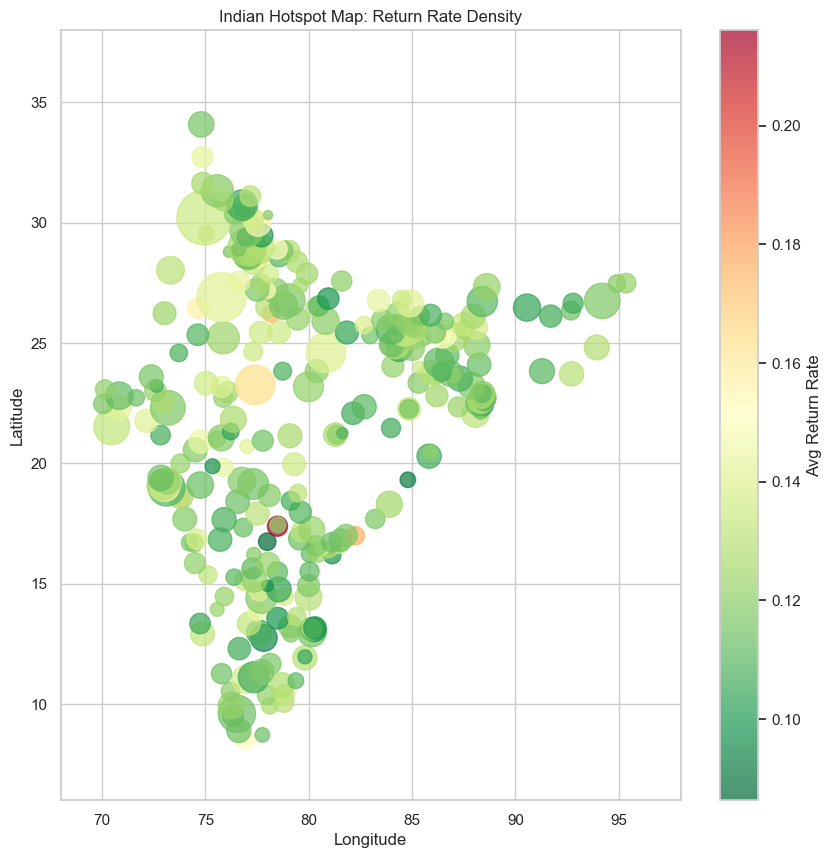

In [15]:
sns.set(style="whitegrid")

# 1. Indian Hotspot Map (Scatter)
plt.figure(figsize=(10, 10))
geo_agg = df.groupby(['Latitude', 'Longitude']).agg({'User_Global_Return_Rate': 'mean', 'Invoice': 'count'}).reset_index()
sc = plt.scatter(x=geo_agg['Longitude'], y=geo_agg['Latitude'], 
                 c=geo_agg['User_Global_Return_Rate'], cmap='RdYlGn_r', 
                 s=geo_agg['Invoice']/10, alpha=0.7)
plt.colorbar(sc, label='Avg Return Rate')
plt.title('Indian Hotspot Map: Return Rate Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(68, 98) # India Longitude bounds
plt.ylim(6, 38)  # India Latitude bounds
plt.show()

In [ ]:
#  Geospatial Density Heatmap (KDE Plot)
plt.figure(figsize=(10, 10))
sns.kdeplot(x=df['Longitude'], y=df['Latitude'], cmap="Reds", fill=True, alpha=0.6, thresh=0.05)
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.1, s=5, color='black')
plt.title('Indian Geospatial Density Heatmap (Return Activity)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(68, 98)
plt.ylim(6, 38)
plt.show()

C:\Users\sanna\AppData\Local\Temp\ipykernel_31768\3058273340.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Is_Return', y='Total_Price', data=price_filtered, palette='muted')


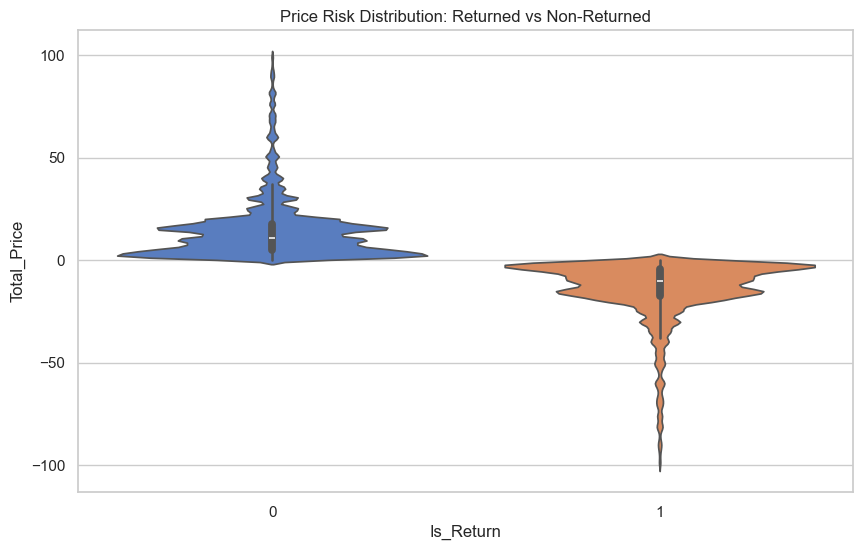

In [21]:
#  Price Risk Distribution (Violin Plot)
plt.figure(figsize=(10, 6))
price_filtered = df[(df['Total_Price'] < 100) & (df['Total_Price'] > -100)] 
sns.violinplot(x='Is_Return', y='Total_Price', data=price_filtered, palette='muted')
plt.title('Price Risk Distribution: Returned vs Non-Returned')
plt.show()

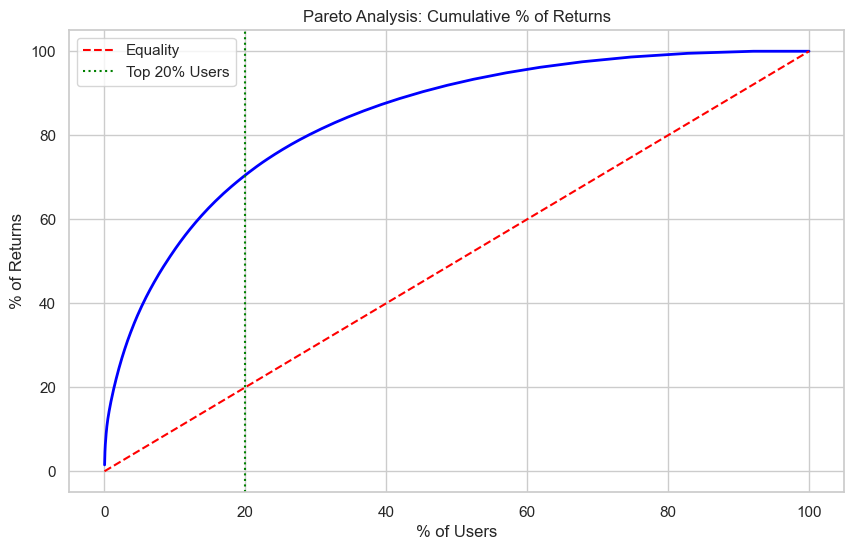

In [22]:
#  Pareto Analysis
plt.figure(figsize=(10, 6))
user_returns = df.groupby('Customer ID')['Is_Return'].sum().sort_values(ascending=False).reset_index()
user_returns['Cum_Returns'] = user_returns['Is_Return'].cumsum()
user_returns['Cum_Return_Pct'] = user_returns['Cum_Returns'] / user_returns['Is_Return'].sum() * 100
user_returns['User_Rank_Pct'] = (user_returns.index + 1) / len(user_returns) * 100
plt.plot(user_returns['User_Rank_Pct'], user_returns['Cum_Return_Pct'], color='blue', linewidth=2)
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Equality')
plt.axvline(x=20, color='green', linestyle=':', label='Top 20% Users')
plt.title('Pareto Analysis: Cumulative % of Returns')
plt.xlabel('% of Users')
plt.ylabel('% of Returns')
plt.legend()
plt.show()

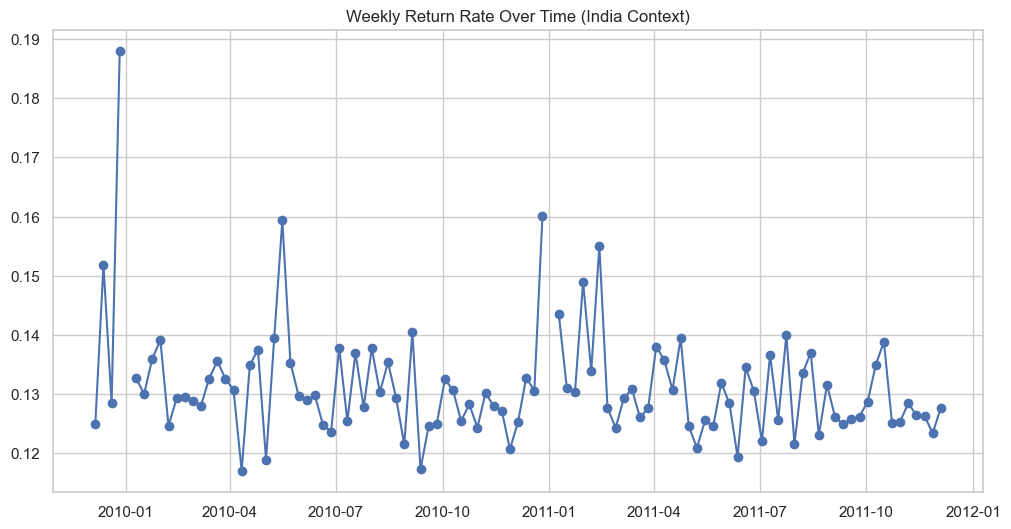

In [23]:
#  Time-Series Seasonality
plt.figure(figsize=(12, 6))
df_ts = df.set_index('InvoiceDate')
weekly_return_rate = df_ts['Is_Return'].resample('W').mean()
plt.plot(weekly_return_rate, marker='o')
plt.title('Weekly Return Rate Over Time (India Context)')
plt.show()

C:\Users\sanna\AppData\Local\Temp\ipykernel_31768\563199301.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Item_Value_Category', y='Is_Return', data=avg_return_rate, palette='viridis')


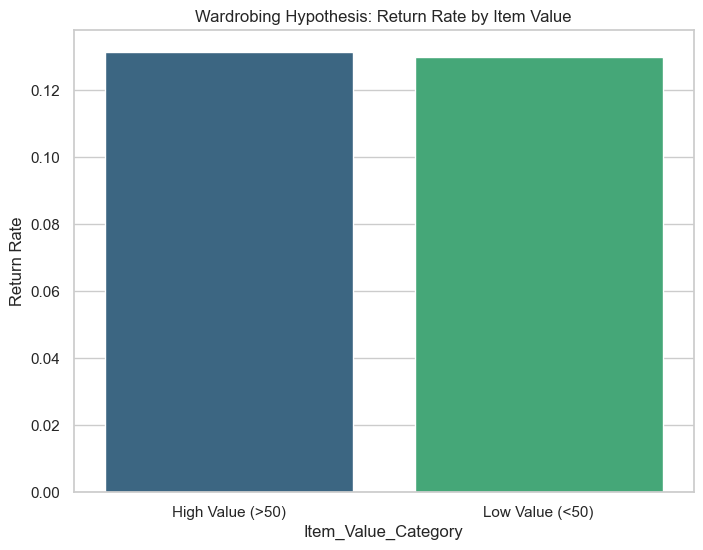

In [24]:
# Wardrobing Hypothesis
plt.figure(figsize=(8, 6))
df['Item_Value_Category'] = np.where(df['Total_Price'].abs() > 50, 'High Value (>50)', 'Low Value (<50)')
avg_return_rate = df.groupby('Item_Value_Category')['Is_Return'].mean().reset_index()
sns.barplot(x='Item_Value_Category', y='Is_Return', data=avg_return_rate, palette='viridis')
plt.title('Wardrobing Hypothesis: Return Rate by Item Value')
plt.ylabel('Return Rate')
plt.show()

## 5. Explicit Hotzone Detection

In [16]:
city_stats = df.groupby(['State', 'City']).agg(
    Total_Invoices=('Invoice', 'nunique'),
    Return_Count=('Is_Return', 'sum')
).reset_index()

In [17]:
city_stats['City_Return_Rate'] = city_stats['Return_Count'] / city_stats['Total_Invoices']
volume_threshold = city_stats['Total_Invoices'].median()
return_rate_threshold = city_stats['City_Return_Rate'].quantile(0.75)

In [18]:
hotzones = city_stats[
    (city_stats['Total_Invoices'] > volume_threshold) & 
    (city_stats['City_Return_Rate'] > return_rate_threshold)
].sort_values(by='City_Return_Rate', ascending=False)

In [19]:
print(hotzones[['State', 'City', 'Total_Invoices', 'City_Return_Rate']].head(10))

              State                  City  Total_Invoices  City_Return_Rate
169     Maharashtra                Panvel             164          4.835366
190          Punjab              Bathinda             424          4.608491
32            Assam                Jorhat             178          4.477528
138  Madhya Pradesh              Jabalpur             137          4.306569
5    Andhra Pradesh           Dharmavaram             165          3.963636
54            Bihar                Munger             145          3.737931
69            Delhi  Kirari Suleman Nagar             150          3.720000
72            Delhi      Sultan Pur Majra             169          3.437870
42            Bihar                 Buxar             162          3.364198
220      Tamil Nadu              Tiruppur             183          3.229508
